# XAI vs No XAI Comparison

Comparing the effect of explainable AI (XAI) guidance on molecule optimization performance for Claude Opus 4.5 and GPT-5.1.

In [11]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import random 

random.seed(42)
np.random.seed(42)


In [12]:
# Define paths
RESULTS_DIR = Path("../../data/results/similarity_qed_pubchem")

# Set to False to hide legend (for combined figures with shared legend)
SHOW_LEGEND = False

# Define experiment groups: (display_name, folder_name)
GROUPS = [
    ("Claude Opus 4.5 (Full XAI)", "claude-opus-4.5_full_xai"),
    ("Claude Opus 4.5 (Partial XAI)", "claude-opus-4.5_partial_xai_None"),
    ("Claude Opus 4.5 (No XAI)", "claude-opus-4.5_no_xai"),
    ("Claude Opus 4.5 (No XAI, no description)", "claude-opus-4.5_no_description_None"),
]

## Loading Data

In [13]:
def load_trace(p: Path) -> list:
    """Load trace from JSON file."""
    d = json.loads(p.read_text(encoding="utf-8"))
    return d["trace"] if isinstance(d, dict) and "trace" in d else d


def load_results_as_df(results_dir: Path, groups: list) -> pd.DataFrame:
    """Load all results from JSON trace files into a DataFrame.
    
    Returns DataFrame with columns: model, target_molecule, iteration, score, smiles
    """
    rows = []
    
    for display_name, folder_name in groups:
        folder_path = results_dir / folder_name
        files = sorted(folder_path.glob("sim_qed_pubchem_*.json"))
        
        if not files:
            raise FileNotFoundError(f"No files in {folder_path} matching sim_qed_pubchem_*.json")
        
        for file_path in files:
            # Extract target molecule (e.g., "mol1", "mol2") from filename
            mol_match = re.search(r'mol\d+', file_path.name)
            target_molecule = mol_match.group() if mol_match else "unknown"
            
            try:
                trace = load_trace(file_path)
                for entry in trace:
                    rows.append({
                        "model": display_name,
                        "target_molecule": target_molecule,
                        "iteration": int(entry["iteration"]),
                        "score": float(entry["score"]),
                        "smiles": entry["smiles"],
                    })
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    return pd.DataFrame(rows)


# Load all results
df = load_results_as_df(RESULTS_DIR, GROUPS)

---
## Best-so-far Progression Plot

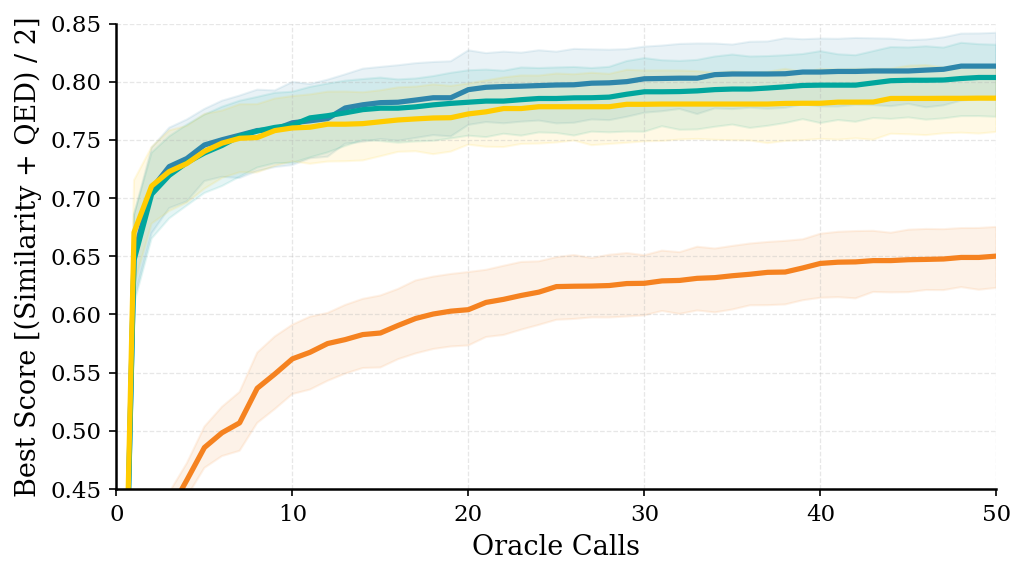

In [14]:
# Compute best-so-far (cummax needs data sorted by iteration)
df["best_so_far"] = (
    df.sort_values("iteration")
    .groupby(["model", "target_molecule"])["score"]
    .cummax()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
max_iter = 50  # Limit to 50 iterations
all_iterations = range(0, max_iter + 1)
df_plot = (
    df[df["iteration"] <= max_iter]
    .pivot_table(index="iteration", columns=["model", "target_molecule"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .fillna(0)  # Baseline at oracle call 0 (no score yet)
    .melt(ignore_index=False)
    .reset_index()
)

# Set publication-quality style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.figsize': (6, 4),
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.6,
    'lines.linewidth': 2.5,
})

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

# Define color palette for explanation conditions
unique_models = df_plot['model'].unique()
model_colors = {
    'Claude Opus 4.5 (Full XAI)': '#2E86AB',
    'Claude Opus 4.5 (Partial XAI)': '#00a69d',
    'Claude Opus 4.5 (No XAI)': '#ffcc00',
    'Claude Opus 4.5 (No XAI, no description)': '#f58220',
}

# Define legend order and labels
legend_order = [
    'Claude Opus 4.5 (Full XAI)',
    'Claude Opus 4.5 (Partial XAI)',
    'Claude Opus 4.5 (No XAI)',
    'Claude Opus 4.5 (No XAI, no description)',
]

legend_labels = {
    'Claude Opus 4.5 (Full XAI)': 'Full explanations',
    'Claude Opus 4.5 (Partial XAI)': 'Partial explanations',
    'Claude Opus 4.5 (No XAI)': 'No explanations',
    'Claude Opus 4.5 (No XAI, no description)': 'No description',
}

# Plot with seaborn (mean + 95% bootstrap CI)
sns.lineplot(
    data=df_plot, 
    x="iteration", 
    y="value", 
    hue="model",
    hue_order=legend_order,
    palette=model_colors,
    errorbar=('ci', 95),
    err_kws={'alpha': 0.1},  # Make confidence interval more transparent
    linewidth=2.5,
    ax=ax
)

# Styling
ax.set_xlabel("Oracle Calls", fontsize=13, fontweight='normal')
ax.set_ylabel("Best Score [(Similarity + QED) / 2]", fontsize=13, fontweight='normal')
ax.set_xlim(0, 50)
ax.set_ylim(0.45, 0.85)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Conditionally show/hide legend
if SHOW_LEGEND:
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [legend_labels.get(label, label) for label in labels]
    legend = ax.legend(
        handles,
        new_labels,
        title='Model',
        frameon=True,
        fancybox=False,
        shadow=False,
        framealpha=0.95,
        edgecolor='black',
        loc='lower right'
    )
    legend.get_frame().set_linewidth(0.5)
else:
    ax.get_legend().remove()

plt.tight_layout()

# Save figure as PDF
plt.savefig('./figures/xai_vs_no_xai_random_molecules.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()

---
## AUC Top-1 over 50 Iterations

In [15]:
def bootstrap_ci(data, n_bootstrap=10000, ci=0.95):
    """Compute bootstrap 95% CI for the mean."""
    data = data.dropna()
    if len(data) < 2:
        return np.nan, np.nan
    result = stats.bootstrap(
        (data.values,), 
        statistic=np.mean, 
        n_resamples=n_bootstrap, 
        confidence_level=ci,
        random_state=42
    )
    return result.confidence_interval.low, result.confidence_interval.high




def compute_auc_top1(group_df, max_oracle_calls=50):
    """Compute AUC of top-1 (best) score vs oracle calls from a dataframe group.
    
    Uses trapezoidal integration (same as PMO benchmark).
    
    Args:
        group_df: DataFrame with 'score' and 'iteration' columns for a single run
        max_oracle_calls: Maximum number of oracle calls (default 50)
    
    Returns:
        AUC value normalized to [0, 1]
    """
    sorted_df = group_df.sort_values('iteration')
    
    best_score = 0.0
    best_at_call = {}
    
    for _, row in sorted_df.iterrows():
        oracle_call = int(row['iteration'])
        score = float(row['score'])
        
        if oracle_call > max_oracle_calls:
            break
        
        if score > best_score:
            best_score = score
        
        best_at_call[oracle_call] = best_score
    
    if not best_at_call:
        return 0.0
    
    oracle_calls = sorted(best_at_call.keys())
    
    # Compute AUC using trapezoidal integration (same as PMO benchmark)
    auc = 0.0
    prev_call = 0
    prev_best = 0.0
    
    for call in oracle_calls:
        # Trapezoidal rule: area = width * (height1 + height2) / 2
        auc += (call - prev_call) * (best_at_call[call] + prev_best) / 2
        prev_call = call
        prev_best = best_at_call[call]
    
    # Extend to max_oracle_calls with the last value
    auc += (max_oracle_calls - prev_call) * prev_best
    
    # Normalize by max_oracle_calls to get average best-so-far score
    return auc / max_oracle_calls


# Compute AUC Top-1 for each model/target_molecule
MAX_ORACLE_CALLS = 50

auc_records = []
for (model, target_mol), group in df.groupby(['model', 'target_molecule']):
    auc = compute_auc_top1(group, MAX_ORACLE_CALLS)
    auc_records.append({
        'model': model,
        'target_molecule': target_mol,
        'auc_top1': auc
    })

auc_df = pd.DataFrame(auc_records)

# Summarize by model with bootstrap CI
auc_summary_rows = []
for model, group in auc_df.groupby('model'):
    values = group['auc_top1']
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    # Compute distances from mean to CI bounds
    ci_low_dist = mean_val - ci_low  # Distance below mean
    ci_high_dist = ci_high - mean_val  # Distance above mean
    auc_summary_rows.append({
        "Model": model,
        "Mean AUC Top-1": mean_val,
        "CI 95% -": ci_low_dist,
        "CI 95% +": ci_high_dist,
        "N": len(values),
    })

auc_summary = pd.DataFrame(auc_summary_rows).set_index("Model").round(3)

print(f"AUC Top-1 over {MAX_ORACLE_CALLS} iterations with 95% Bootstrap CI")
auc_summary

AUC Top-1 over 50 iterations with 95% Bootstrap CI


,Mean AUC Top-1,CI 95% -,CI 95% +,N
Model,,,,
Claude Opus 4.5 (Full XAI),0.778,0.031,0.027,20
Claude Opus 4.5 (No XAI),0.761,0.033,0.025,20
"Claude Opus 4.5 (No XAI, no description)",0.588,0.027,0.023,20
Claude Opus 4.5 (Partial XAI),0.770,0.035,0.024,20
